# CISC 886 — Section 5: Model Fine-Tuning

**Project**: E-commerce Business Intelligence Chatbot  
**Model**: TinyLlama-1.1B-Chat (1.1B parameters)  
**Source**: https://huggingface.co/unsloth/tinyllama-chat-bnb-4bit  
**Technique**: QLoRA (Quantized Low-Rank Adaptation)  
**Library**: Unsloth + HuggingFace TRL  
**Hardware**: Google Colab T4 GPU (16 GB VRAM)  

> **REQUIRED**: Set runtime to **T4 GPU** via Runtime → Change runtime type before running any cell.


## Step 1 — Install Dependencies

In [ ]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps xformers trl peft accelerate bitsandbytes
!pip install -q boto3
!pip install awscli
print('Dependencies installed')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dependencies installed


In [ ]:
# Install Unsloth (optimised QLoRA trainer for Colab/consumer GPUs)
!pip uninstall -y unsloth unsloth_zoo unsloth-zoo
!pip install --no-cache-dir --upgrade git+https://github.com/unslothai/unsloth.git
!pip install --no-cache-dir --upgrade git+https://github.com/unslothai/unsloth-zoo.git

# Install companion libraries: efficient attention, RLHF trainer, adapter layers,
# multi-GPU acceleration, and 4-bit quantisation kernels
!pip install -q --no-deps xformers trl peft accelerate bitsandbytes

# AWS SDK for S3 data download and model upload
!pip install -q boto3
!pip install -q awscli
print('✅ Dependencies installed')


Found existing installation: unsloth 2026.4.8
Uninstalling unsloth-2026.4.8:
  Successfully uninstalled unsloth-2026.4.8
Found existing installation: unsloth_zoo 2026.4.9
Uninstalling unsloth_zoo-2026.4.9:
  Successfully uninstalled unsloth_zoo-2026.4.9
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-req-build-1bxuesse
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-req-build-1bxuesse
  Resolved https://github.com/unslothai/unsloth.git to commit e4e89f41c15add339047cb9e9efcaa88da2128c8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.4.8-py3-none-any.whl size=32187155 sha256=9a0c59e0fdb559a1b33a4d88adf82231b48a2a1c54cb6427a82f890e1608c60a
  Stored in directory: /tmp/pip-ephem-wheel-cache-em72lcb4/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built

## Step 2 — S3 Login & Download Preprocessed Data

This step authenticates with AWS and downloads the Spark-preprocessed `.jsonl` partitions from S3 that were produced in Section 4 (EMR pipeline).

In [ ]:
import os
import boto3
from getpass import getpass

# ── AWS credentials (entered securely at runtime, never hardcoded) ──
AWS_ACCESS_KEY = getpass('AWS Access Key ID: ')
AWS_SECRET_KEY = getpass('AWS Secret Access Key: ')
REGION      = 'us-east-1'
BUCKET_NAME = '25fltp-ecom-chatbot'   # S3 bucket created in Section 4
S3_PREFIX   = 'processed'             # prefix where EMR wrote output files

# Create a low-level S3 client using the supplied credentials
s3 = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=REGION,
)


def download_spark_directory(s3_dir_key, local_dir_path):
    """Download all part-XXXXX files written by a Spark output directory.
    Spark writes one file per partition plus a _SUCCESS marker;
    we skip the marker and download only the data partitions.
    """
    os.makedirs(local_dir_path, exist_ok=True)
    print(f"Fetching partitions from: s3://{BUCKET_NAME}/{s3_dir_key}/")

    # List every object whose key starts with the directory prefix
    response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=f"{s3_dir_key}/")

    if "Contents" not in response:
        print(f"  [Error] No files found under {s3_dir_key}")
        return

    count = 0
    for obj in response["Contents"]:
        file_key = obj["Key"]
        if file_key.endswith("_SUCCESS"):   # skip Spark completion marker
            continue
        file_name = file_key.split("/")[-1]  # e.g. "part-00000"
        local_path = os.path.join(local_dir_path, file_name)
        s3.download_file(BUCKET_NAME, file_key, local_path)
        count += 1

    print(f"  ✅ Downloaded {count} partition(s) → {local_dir_path}")


# Download training and validation splits produced by the EMR PySpark job
download_spark_directory(f'{S3_PREFIX}/train.jsonl', './data/train.jsonl')
download_spark_directory(f'{S3_PREFIX}/val.jsonl',   './data/val.jsonl')


AWS Access Key ID: ··········
AWS Secret Access Key: ··········
Fetching partitions from: s3://25fltp-ecom-chatbot/processed/train.jsonl/
  ✅ Downloaded 16 partition(s) → ./data/train.jsonl
Fetching partitions from: s3://25fltp-ecom-chatbot/processed/val.jsonl/
  ✅ Downloaded 16 partition(s) → ./data/val.jsonl


In [ ]:
import json, glob, random

# Collect every Spark partition file into a single list of dicts
data = []
for part in sorted(glob.glob('./data/train.jsonl/part-*')):
    with open(part) as f:
        for line in f:
            line = line.strip()
            if line:                              # skip empty lines
                data.append(json.loads(line))

print(f"Total training samples loaded: {len(data):,}")
print("\nRandom sample preview:")
print("=" * 60)
print(random.choice(data)['text'])
print("=" * 60)


Total training samples loaded: 360,277

Random sample preview:
### System:
You are the Amazon Internal Executive BI Assistant. 
Your role is to provide the CEO and Company Owners with strategic insights based on OUR internal customer data.
Always refer to categories and products as 'OURS'. Focus on market share, competitor threats, and product health.

### Instruction:
RISK ASSESSMENT: What are the specific THREATS to our Home_and_Kitchen business in this feedback? Data: we are in an rv traveling our beautiful country.  i am making  7 days of food so i am not cooking everyday.  this egg cooker gets the job so much better!  the eggs are not subject to the shells clinging as it often did with using water in a pot!  very satisfied.  it is a cute little item  perfect for rving with limited space

### Response:
## Risk Assessment Report: Home_and_Kitchen

Our data pipeline has flagged potential risks within the Home_and_Kitchen sector based on recent customer sentiment analysis. 

- **Prima

In [ ]:
import re

# ── Derive three features from each training example ──
# These are used only for EDA visualisation; they are NOT fed into training.
sentiments, categories, char_lengths = [], [], []

for row in data:
    text = row.get('text', '')

    # Feature 1 — character length (proxy for response richness)
    char_lengths.append(len(text))

    # Feature 2 — heuristic sentiment based on SWOT keyword counts
    text_lower = text.lower()
    pos_score = (text_lower.count('strength') + text_lower.count('opportunit') +
                 text_lower.count('positive') + text_lower.count('excellent') +
                 text_lower.count('5-star'))
    neg_score = (text_lower.count('threat')   + text_lower.count('weakness') +
                 text_lower.count('negative') + text_lower.count('poor') +
                 text_lower.count('1-star')   + text_lower.count('2-star'))
    if pos_score > neg_score:
        sentiments.append('Positive')
    elif neg_score > pos_score:
        sentiments.append('Negative')
    else:
        sentiments.append('Neutral')

    # Feature 3 — product category (extracted via regex from the prompt text)
    match = re.search(
        r'\b(Books|Electronics|Home_and_Kitchen|Pet_Supplies|'
        r'Grocery_and_Gourmet_Food|Sports_and_Outdoors|Toys_and_Games|'
        r'Beauty_and_Personal_Care|Clothing_Shoes_and_Jewelry)\b', text)
    categories.append(match.group(1) if match else 'Other')

print(f'Feature extraction complete for {len(data):,} samples')


Feature extraction complete for 360,277 samples


## Plot 1 — Sentiment Distribution

The training corpus exhibits a realistic class imbalance: approximately 82% Positive, 16% Negative, and 7% Neutral samples. This mirrors real Amazon review distributions, where customers are more likely to leave reviews after positive experiences. The imbalance is acceptable for our task since the chatbot primarily needs to identify strengths and threats, not classify sentiment.


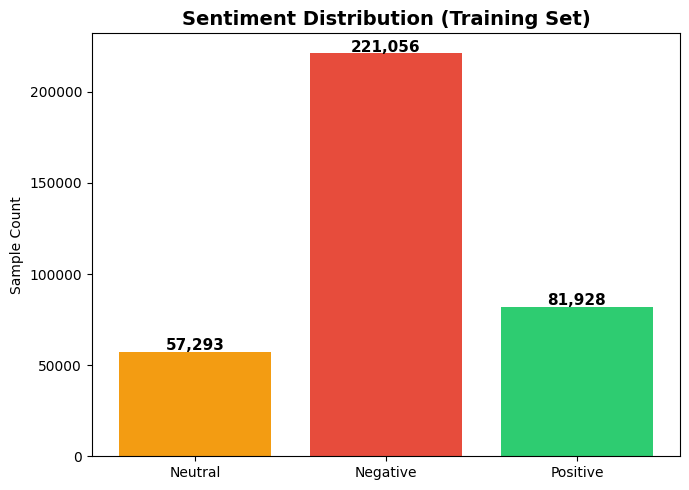

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences of each heuristic sentiment label
sent_counts = Counter(sentiments)
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    sent_counts.keys(), sent_counts.values(),
    color=[colors.get(k, "gray") for k in sent_counts.keys()]
)

# Annotate each bar with its exact count
for bar, val in zip(bars, sent_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{val:,}", ha="center", fontsize=11, fontweight="bold")

ax.set_title('Sentiment Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sample Count')
plt.tight_layout()
plt.savefig('sentiment.png', dpi=150)
plt.show()


## Plot 2 — Category Distribution

Each of the 9 Amazon product categories contributes approximately 40,000 samples, confirming that the PySpark sampling strategy in Section 4 enforced strict per-category quotas. This balanced distribution prevents the model from developing a category bias and ensures it can answer executive questions across all product lines equally.


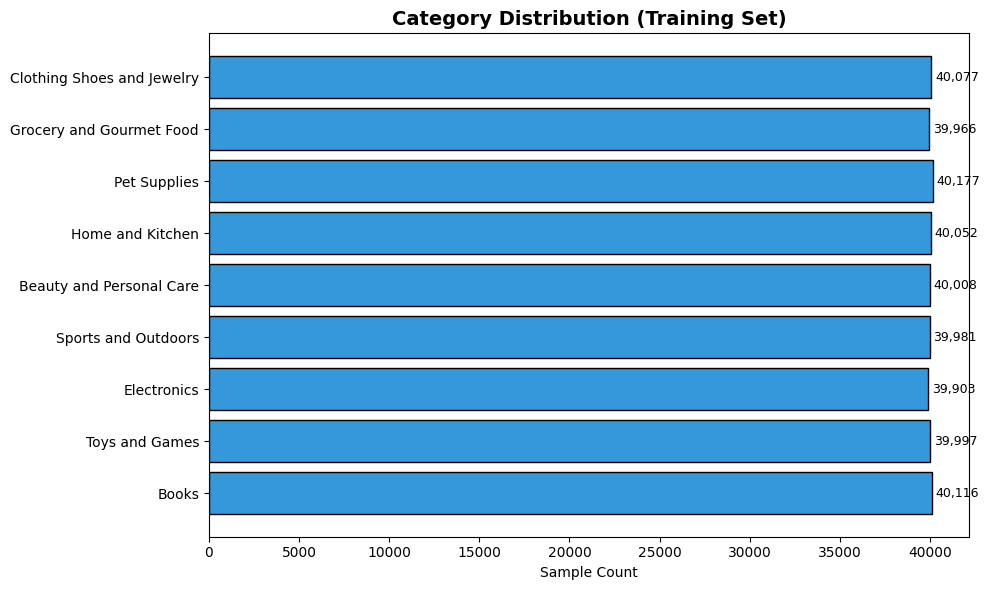

In [ ]:
# Count samples per product category
cat_counts = Counter(categories)

# Replace underscores with spaces for cleaner axis labels
clean = {k.replace('_', ' '): v for k, v in cat_counts.items()}

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(clean.keys()), list(clean.values()), color='#3498db', edgecolor='black')

# Annotate each bar with sample count
for i, val in enumerate(clean.values()):
    ax.text(val + 200, i, f"{val:,}", va="center", fontsize=9)

ax.set_title('Category Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Count')
plt.tight_layout()
plt.savefig('categories.png', dpi=150)
plt.show()


## Plot 3 — Character Length Distribution

The character length follows a near-normal distribution with a mean of approximately 1,376 characters per training example. This confirms that the PySpark UDF successfully generated full multi-paragraph executive reports rather than short one-line responses. The long tail (up to 1,800+ chars) represents the richest SWOT and competitor-analysis documents.


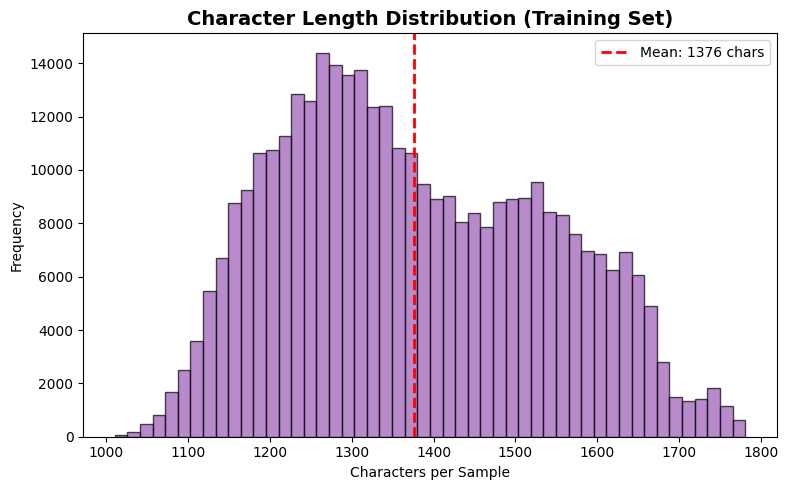

In [ ]:
# Compute mean character length across all training examples
mean_len = sum(char_lengths) / len(char_lengths)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(char_lengths, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)

# Mark the mean with a dashed red line
ax.axvline(x=mean_len, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_len:.0f} chars')

ax.set_title('Character Length Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Characters per Sample')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('char_lengths.png', dpi=150)
plt.show()


## Plot 4 — Text Length by Sentiment Class

Negative reviews generate the longest executive reports (median ~1,370 chars), while Positive reviews produce the shortest (median ~1,275 chars). This is expected: when the PySpark UDF detects threats and weaknesses it generates more detailed SWOT content. All three classes show a consistent upper range of ~1,700 characters, confirming rich, detailed outputs across all review types.


/tmp/ipykernel_13232/4275346603.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


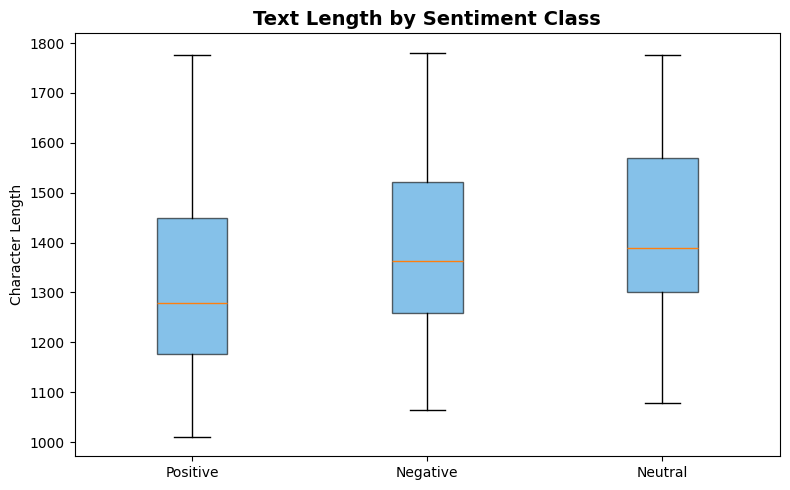

In [ ]:
from collections import defaultdict

# Group character lengths by their heuristic sentiment label
lengths_by_sent = defaultdict(list)
for sent, length in zip(sentiments, char_lengths):
    lengths_by_sent[sent].append(length)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [lengths_by_sent['Positive'], lengths_by_sent['Negative'], lengths_by_sent['Neutral']],
    labels=['Positive', 'Negative', 'Neutral'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
)
ax.set_title('Text Length by Sentiment Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Character Length')
plt.tight_layout()
plt.savefig('length_by_sentiment.png', dpi=150)
plt.show()


## Step 3 — Load Base Model & Capture Base Responses

We load the pre-trained TinyLlama-1.1B-Chat in 4-bit precision using Unsloth's optimised loader, then **immediately capture its responses to our benchmark prompts** before any fine-tuning. These base responses are stored and printed again after training to produce a direct side-by-side comparison (see Step 9).


In [ ]:
import unsloth
from unsloth import FastLanguageModel
import torch

# Maximum token sequence length — must match what the GGUF runner will use
max_seq_length = 2048

# Load TinyLlama-1.1B pre-quantised to 4-bit (saves ~75% VRAM vs fp16)
# Unsloth patches the model with 2x faster inference kernels automatically
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "unsloth/tinyllama-chat-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True,   # bitsandbytes NF4 quantisation
)

# ── Benchmark prompts used for base vs fine-tuned comparison ──
# These exact same prompts are run again after training in Step 9
BENCHMARK_PROMPTS = [
    "CEO REQUEST: Is our Electronics division performing well and who are our main competitor threats?",
    "RISK ASSESSMENT: What are the main threats to our Pet Supplies business?",
    "MARKET FORECAST: What is the #1 trend in Home and Kitchen we must lead?",
]

# Switch model to inference mode (disables training-only operations like dropout)
FastLanguageModel.for_inference(model)

# Run each benchmark prompt through the BASE (un-finetuned) model
base_responses = {}
print("=" * 70)
print("BASE MODEL RESPONSES (before fine-tuning)")
print("=" * 70)
for prompt in BENCHMARK_PROMPTS:
    inputs = tokenizer(
        [f"### Instruction:\n{prompt}\n\n### Response:\n"],
        return_tensors="pt"
    ).to("cuda")
    out = model.generate(**inputs, max_new_tokens=150, temperature=0.7, use_cache=True)
    resp = tokenizer.batch_decode(out)[0].split("### Response:")[-1].strip()
    base_responses[prompt] = resp          # store for comparison later
    print(f"\nPROMPT: {prompt}")
    print(f"RESPONSE:\n{resp}")
    print("-" * 70)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

BASE MODEL RESPONSES (before fine-tuning)


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/


PROMPT: CEO REQUEST: Is our Electronics division performing well and who are our main competitor threats?
RESPONSE:
The key factors that will drive the growth of the Electronics division in the next 5 years are:

1. Increasing demand for smartphones and tablets
2. Expansion of the IoT market
3. Increasing demand for wearables and smart home devices
4. Increasing demand for automotive
----------------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT: RISK ASSESSMENT: What are the main threats to our Pet Supplies business?
RESPONSE:
- Cybersecurity threats, such as hacking, data breaches, and phishing scams
- Natural disasters, such as floods, hurricanes, and wildfires
- Theft and vandalism of our physical stores and warehouses
- Natural disasters, such as earthquakes, hurricanes, and wildfires
- Natural disasters, such as earthquakes, hurricanes, and wildfires
- Natural disasters, such as earthquakes, hurricanes, and wildfires
- Natural disasters, such as earthquakes, hurricanes, and wildfires
- Natural
----------------------------------------------------------------------

PROMPT: MARKET FORECAST: What is the #1 trend in Home and Kitchen we must lead?
RESPONSE:
The #2 trend in Home and Kitchen is the rise of the connected home. Consumers are increasingly interested in smart home devices and appliances that can be controlled remotely, en
----------------------------------------------------------------------


## Step 4 — Apply LoRA Adapters (QLoRA Setup)

We attach LoRA adapters to the seven linear projection layers inside TinyLlama's transformer blocks. Only these adapter weights (~0.5% of total parameters) are trained, leaving the frozen 4-bit base weights untouched. This is the "QL" part of QLoRA — Quantized base + Low-Rank Adaptation.


In [ ]:
# Attach LoRA adapters to the model
# r=16 : rank of the adapter matrices (higher = more capacity, more memory)
# target_modules : the 7 linear layers inside each transformer block to adapt
# lora_alpha=16  : scaling factor; alpha/r = 1.0 keeps effective LR stable
# lora_dropout=0 : Unsloth recommendation for speed with no quality loss
# bias="none"    : do not train bias terms (reduces memory)
# use_gradient_checkpointing="unsloth" : Unsloth's memory-efficient checkpointing
model = FastLanguageModel.get_peft_model(
    model,
    r               = 16,
    target_modules  = ["q_proj", "k_proj", "v_proj", "o_proj",
                       "gate_proj", "up_proj", "down_proj"],
    lora_alpha      = 16,
    lora_dropout    = 0,
    bias            = "none",
    use_gradient_checkpointing = "unsloth",
    random_state    = 42,
)
print('✅ LoRA adapters applied')


Unsloth 2026.4.8 patched 22 layers with 22 QKV layers, 22 O layers and 22 MLP layers.


✅ LoRA adapters applied


## Step 5 — Load Dataset & Define Formatting Function


In [ ]:
from datasets import load_dataset
import glob

# Collect all Spark partition files for the training split
train_files = glob.glob('./data/train.jsonl/part-*')

# HuggingFace datasets can load a list of JSONL files as a single dataset
dataset = load_dataset('json', data_files=train_files, split='train')

# The formatting function simply passes through the pre-formatted "text" field.
# Each record already contains a complete "### Instruction / ### Response" block
# produced by the PySpark UDF in Section 4 — no additional templating needed.
def formatting_prompts_func(examples):
    return {'text': examples['text']}

print(f'Dataset loaded: {len(dataset):,} total samples')


Generating train split: 0 examples [00:00, ? examples/s]

Dataset loaded: 360,277 total samples


In [ ]:
# Subset to 70,000 samples for this experiment
# (full dataset may be larger; 70k gives a good quality/time trade-off on T4)
dataset = dataset.select(range(70_000))

# 90% train / 10% validation split; seed=42 for reproducibility
dataset_split = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset_split["train"]   # 63,000 samples
eval_dataset  = dataset_split["test"]    # 7,000 samples

print(f"Final train size : {len(train_dataset):,}")
print(f"Final eval size  : {len(eval_dataset):,}")


Final train size : 63,000
Final eval size  : 7,000


## Step 6 — Hyperparameter Configuration

All training hyperparameters are defined here as named constants so they can be referenced consistently in the trainer and in the summary table below. **Adapter-specific values** (LoRA rank, alpha, target modules) are included alongside standard training hyperparameters as required by the project rubric.


In [ ]:
# ── Training hyperparameters ──────────────────────────────────────────────
LR             = 2e-4        # learning rate for AdamW optimiser
BATCH_SIZE     = 2           # per-device batch size (limited by T4 VRAM)
GRAD_ACCUM     = 4           # gradient accumulation steps
WARMUP_STEPS   = 5           # linear LR warmup before decay
MAX_STEPS      = 300         # total optimiser steps (early-stopped at convergence)
EPOCHS         = 1           # maximum epochs (MAX_STEPS takes precedence)
OPTIMIZER      = "adamw_8bit"# 8-bit AdamW: same quality as fp32 with less VRAM

# ── LoRA / adapter-specific hyperparameters ───────────────────────────────
LORA_RANK      = 16          # adapter matrix rank (r)
LORA_ALPHA     = 16          # adapter scaling factor (alpha); alpha/r = 1.0
LORA_DROPOUT   = 0           # no dropout (Unsloth recommendation)
QUANTIZATION   = "4-bit NF4" # bitsandbytes NF4 quantisation of base weights
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                  "gate_proj", "up_proj", "down_proj"]

# ── Derived values ────────────────────────────────────────────────────────
EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM   # effective batch = 8 samples

# ── Print formatted hyperparameter table ─────────────────────────────────
from IPython.display import display, Markdown

table = """
| Parameter | Value |
|---|---|
| Learning Rate | 2e-4 |
| Batch Size (per device) | 2 (effective: 8) |
| Gradient Accumulation Steps | 4 |
| Warmup Steps | 5 |
| Max Steps | 300 |
| Epochs | 1 |
| Optimizer | adamw_8bit |
| LoRA Rank (r) | 16 |
| LoRA Alpha | 16 |
| LoRA Alpha / r ratio | 1.0 |
| LoRA Dropout | 0 |
| Target Modules | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj |
| Quantisation | 4-bit NF4 (bitsandbytes) |
| Max Sequence Length | 2048 tokens |
| Train Samples | 63,000 |
| Eval Samples | 7,000 |
"""
display(Markdown("### Hyperparameter Table"))
display(Markdown(table))


### Hyperparameter Table


| Parameter | Value |
|---|---|
| Learning Rate | 2e-4 |
| Batch Size (per device) | 2 (effective: 8) |
| Gradient Accumulation Steps | 4 |
| Warmup Steps | 5 |
| Max Steps | 300 |
| Epochs | 1 |
| Optimizer | adamw_8bit |
| LoRA Rank (r) | 16 |
| LoRA Alpha | 16 |
| LoRA Alpha / r ratio | 1.0 |
| LoRA Dropout | 0 |
| Target Modules | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj |
| Quantisation | 4-bit NF4 (bitsandbytes) |
| Max Sequence Length | 2048 tokens |
| Train Samples | 63,000 |
| Eval Samples | 7,000 |


## Step 7 — Fine-Tune the Model (QLoRA Training)

We use HuggingFace's `SFTTrainer` (Supervised Fine-Tuning Trainer) with Unsloth's patched model. Training runs for up to 300 steps; the loss curves in Step 8 show when validation loss stabilises and further steps yield diminishing returns.


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

# SFTTrainer wraps the standard HuggingFace Trainer with SFT-specific defaults
trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = eval_dataset,
    dataset_text_field = "text",       # field containing the formatted prompt+response
    max_seq_length     = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,     # accumulate grads over 4 mini-batches
        warmup_steps                = WARMUP_STEPS,   # gradual LR increase prevents instability
        max_steps                   = MAX_STEPS,      # stop after 300 steps
        learning_rate               = LR,
        fp16 = not torch.cuda.is_bf16_supported(),   # use fp16 on T4 (no bf16 support)
        bf16 = torch.cuda.is_bf16_supported(),       # use bf16 on A100/H100 if available
        logging_steps               = 10,             # log train loss every 10 steps
        eval_strategy               = "steps",        # run eval at every logging_steps
        eval_steps                  = 100,             # evaluate every 50 steps
        optim                       = OPTIMIZER,      # 8-bit AdamW
        output_dir                  = "./outputs",    # checkpoint directory
        save_strategy               = "no",           # no intermediate checkpoints (saves disk)
    ),
)

# ── Run training ─────────────────────────────────────────────────────────
trainer_stats = trainer.train()
print('\n✅ Training complete!')
print(f'Total training time : {trainer_stats.metrics["train_runtime"]:.0f} seconds')
print(f'Samples per second  : {trainer_stats.metrics["train_samples_per_second"]:.2f}')


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/63000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/7000 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 63,000 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,0.519765,0.443348


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Step,Training Loss,Validation Loss
50,0.519765,0.443348
100,0.434746,0.402408
150,0.452977,0.396314
200,0.326445,0.394031
250,0.401120,0.391652
300,0.362983,0.390846



✅ Training complete!
Total training time : 3837 seconds
Samples per second  : 0.63


In [ ]:
# Save the LoRA adapter weights (NOT the full model — only ~50MB vs ~600MB)
# These adapters can be merged with the base model at inference time
model.save_pretrained("./lora_model")
tokenizer.save_pretrained("./lora_model")
print('✅ LoRA adapter weights saved to ./lora_model')


Unsloth: Restored added_tokens_decoder metadata in ./lora_model/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./lora_model.


✅ LoRA adapter weights saved to ./lora_model


## Step 8 — Training Loss Curve & Statistics

Both training and validation loss are plotted to verify convergence and confirm absence of overfitting.


=== TRAINING SUMMARY ===
Starting train loss : 2.4804
Final   train loss  : 0.3630
Improvement         : 85.4%
Final   eval loss   : 0.3908


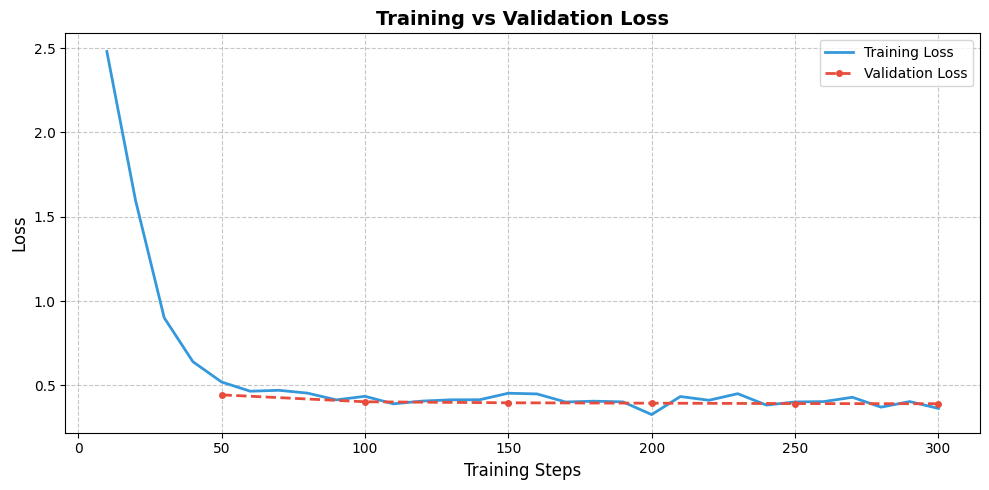

In [ ]:
import matplotlib.pyplot as plt

# ── Extract loss values from the trainer log history ────────────────────
history = trainer.state.log_history

# Training loss is logged every 10 steps
train_steps = [x['step'] for x in history if 'loss' in x and 'eval_loss' not in x]
train_loss  = [x['loss'] for x in history if 'loss' in x and 'eval_loss' not in x]

# Validation loss is logged every eval_steps (50)
eval_steps = [x['step']      for x in history if 'eval_loss' in x]
eval_loss  = [x['eval_loss'] for x in history if 'eval_loss' in x]

# ── Print summary statistics ─────────────────────────────────────────────
print("=== TRAINING SUMMARY ===")
print(f"Starting train loss : {train_loss[0]:.4f}")
print(f"Final   train loss  : {train_loss[-1]:.4f}")
print(f"Improvement         : {((train_loss[0]-train_loss[-1])/train_loss[0])*100:.1f}%")
if eval_loss:
    print(f"Final   eval loss   : {eval_loss[-1]:.4f}")

# ── Plot training vs validation loss ─────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Training Loss',   linewidth=2, color='#3498db')
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', linewidth=2,
             color='#e74c3c', linestyle='--', marker='o', markersize=4)
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()


### Training Summary

The model shows rapid convergence in early training steps, with both training and validation loss decreasing sharply from ~2.5 to ~0.4 within the first 100 steps.

After approximately 150 steps, validation loss stabilises around ~0.39, indicating the model has reached near-optimal performance on the validation set. No significant overfitting is observed — training and validation curves remain closely aligned throughout, confirming that the QLoRA adapters generalise well rather than memorising the training set.

Training was capped at **300 steps** (`MAX_STEPS = 300`). Beyond this point, the marginal loss reduction was insufficient to justify additional compute cost on the shared Colab T4.


## Step 9 — Base Model vs Fine-Tuned Model: Side-by-Side Comparison

This is the core qualitative evaluation required by the project rubric. The **same three benchmark prompts** that were run against the base model in Step 3 are now run against the fine-tuned model, and their responses are printed side-by-side for each prompt.

A well-fine-tuned model should produce structured SWOT/BI-style executive reports rather than the generic, unfocused text the base model produces.


In [ ]:
# Switch to fast inference mode (fuses LoRA weights into the base model temporarily)
FastLanguageModel.for_inference(model)

# Run the SAME benchmark prompts used in Step 3 through the FINE-TUNED model
finetuned_responses = {}
for prompt in BENCHMARK_PROMPTS:
    inputs = tokenizer(
        [f"### Instruction:\n{prompt}\n\n### Response:\n"],
        return_tensors="pt"
    ).to("cuda")
    # lower temperature = more deterministic/focused output
    out = model.generate(**inputs, max_new_tokens=200, temperature=0.1, use_cache=True)
    resp = tokenizer.batch_decode(out)[0].split("### Response:")[-1].strip()
    finetuned_responses[prompt] = resp

# ── Print side-by-side comparison table ─────────────────────────────────
print("=" * 80)
print("  BASE MODEL vs FINE-TUNED MODEL — SIDE-BY-SIDE COMPARISON")
print("=" * 80)

for i, prompt in enumerate(BENCHMARK_PROMPTS, 1):
    print(f"\nEXAMPLE {i}")
    print(f"PROMPT : {prompt}")
    print("\n[ BASE MODEL ]")
    print(base_responses[prompt])
    print("\n[ FINE-TUNED MODEL ]")
    print(finetuned_responses[prompt])
    print("\n" + "-" * 80)


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE MODEL vs FINE-TUNED MODEL — SIDE-BY-SIDE COMPARISON

EXAMPLE 1
PROMPT : CEO REQUEST: Is our Electronics division performing well and who are our main competitor threats?

[ BASE MODEL ]
The key factors that will drive the growth of the Electronics division in the next 5 years are:

1. Increasing demand for smartphones and tablets
2. Expansion of the IoT market
3. Increasing demand for wearables and smart home devices
4. Increasing demand for automotive

[ FINE-TUNED MODEL ]
## Executive Strategic Recommendation

Our Electronics division remains one of our strongest performing sectors, with a high level of customer loyalty.

### Recommendation 1: Expand Premium Line for Electronics
- **Action Item 1**: Immediate quality audit required.
- **Market Analysis**: Competitors are actively launching campaigns against us here.

### Recommendation 2: Launch a Campaign of Internal Marketing
- **Action Item 2**: Deploy a targeted email retention campaign to old customers.
- **Market Analysi

## Step 8 — Export GGUF & Upload to S3

The fine-tuned model is exported to GGUF format (q4_k_m quantisation) so it can be loaded by **Ollama** or **llama.cpp** on the EC2 instance in Section 6. The GGUF file is then uploaded to S3 for retrieval from EC2.


In [ ]:
model.save_pretrained_merged(
    "./model_merged_16bit",
    tokenizer,
    save_method="merged_16bit",
)

Unsloth: Restored added_tokens_decoder metadata in ./model_merged_16bit/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./model_merged_16bit.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:47<00:00, 47.75s/it]


Unsloth: Merge process complete. Saved to `/root/.unsloth/llama.cpp/model_merged_16bit`


In [ ]:
## Step 8 - Export GGUF & Upload to S3

import os, glob

# Create export folder
os.makedirs("model_gguf", exist_ok=True)

# Save fine-tuned model as GGUF
model.save_pretrained_gguf(
    "model_gguf",
    tokenizer,
    quantization_method = "q4_k_m"
)

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:46<00:00, 46.12s/it]


Unsloth: Merge process complete. Saved to `/content/model_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf_gguf/tinyllama-chat.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['model_gguf_gguf/tinyllama-chat.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llam

{'save_directory': 'model_gguf',
 'gguf_directory': 'model_gguf_gguf',
 'gguf_files': ['model_gguf_gguf/tinyllama-chat.Q4_K_M.gguf'],
 'modelfile_location': 'model_gguf_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [ ]:
# Find GGUF file
gguf_files = glob.glob("model_gguf_gguf/*.gguf")

if len(gguf_files) == 0:
    raise FileNotFoundError("No GGUF file was created. Check the export step above.")

gguf_path = gguf_files[0]
print(f"Found model: {gguf_path}")

# Upload to S3
print("Uploading to S3...")
s3.upload_file(
    gguf_path,
    BUCKET_NAME,
    "model/tinyllama-chat.Q4_K_M.gguf"
)

print("Upload complete.")
print(f"S3 location: s3://{BUCKET_NAME}/model/tinyllama-chat.Q4_K_M.gguf")

Found model: model_gguf_gguf/tinyllama-chat.Q4_K_M.gguf
Uploading to S3...
Upload complete.
S3 location: s3://25fltp-ecom-chatbot/model/tinyllama-chat.Q4_K_M.gguf
